# Week 8: Natural Language Processing

## What is NLP, and why is text hard for machine learning?

Natural Language Processing (NLP) is the branch of machine learning concerned with making computers understand, generate, and reason about human language.

The central problem is simple to state: machine learning models work with numbers. Text is not numbers. Before any model can learn from a sentence, that sentence has to be transformed into a numeric representation — and the choices you make in that transformation have enormous consequences for what your model can and cannot learn.

Some of what makes text hard:

- **Vocabulary is huge and open-ended.** The English language has hundreds of thousands of words, and new terms appear constantly. Any fixed numeric representation has to deal with words it has never seen.
- **Order matters.** "The dog bit the man" and "The man bit the dog" contain the exact same words but mean completely different things.
- **Meaning is contextual.** The word "bank" means something different in "river bank" and "savings bank." Treating words as atomic, context-free objects loses this richness.
- **Language is hierarchical.** Words combine into phrases, phrases into clauses, clauses into sentences, sentences into paragraphs. Meaning emerges at every level.

This notebook walks through the main techniques for turning text into something a model can work with, from the simplest approaches (bag of words) to more powerful learned representations (word embeddings), and ends with a working text classifier and a hands-on demo.

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

## Tokenization: breaking text into units

Before we can represent text numerically, we need to decide what the basic unit of analysis is. **Tokenization** is the process of splitting text into these units, called **tokens**.

The simplest approach is to split on whitespace and punctuation, treating each word as a token. But even this hides decisions:
- Should "don't" be one token or two (`don` + `t`)?
- Should `"New York"` be one token or two?
- Should we lowercase everything? Strip punctuation?

Once tokenized, the most common representation is the **bag of words**: count how many times each token appears in the document, and discard all information about order. The document becomes a vector of counts, one entry per word in the vocabulary.

### Why is bag of words a bag?

The name is intentional. Imagine taking all the words in a sentence and tossing them into a bag — you can reach in and pull out words, and you know how many of each you have, but you have lost all sense of sequence. The sentence _"The cat sat on the mat"_ and _"The mat sat on the cat"_ produce identical bags.

In [2]:
from collections import Counter

sentence = "The cat sat on the mat"
tokens = sentence.lower().split()
bag_of_words = Counter(tokens)

print("Tokens:", tokens)
print("Bag of words:", dict(bag_of_words))

Tokens: ['the', 'cat', 'sat', 'on', 'the', 'mat']
Bag of words: {'the': 2, 'cat': 1, 'sat': 1, 'on': 1, 'mat': 1}


### N-grams: capturing some local context

One way to recover a little bit of word order is to use **n-grams**: sequences of N consecutive tokens treated as a single unit.

- A **unigram** is a single word — the standard bag of words.
- A **bigram** is a pair of consecutive words: `("the", "cat")`, `("cat", "sat")`, etc.
- A **trigram** is a triple of consecutive words.

Adding bigrams or trigrams to a bag-of-words representation gives the model access to common phrases and some local order — enough to distinguish "not good" from "good" or "New York" from "New" and "York" separately.

The tradeoff is that higher-order n-grams increase the size of the vocabulary dramatically, since there are far more possible pairs of words than individual words.

In [3]:
def get_ngrams(tokens, n):
    return [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

tokens = "the cat sat on the mat".split()

print("Unigrams:", get_ngrams(tokens, 1))
print()
print("Bigrams: ", get_ngrams(tokens, 2))
print()
print("Trigrams:", get_ngrams(tokens, 3))

Unigrams: [('the',), ('cat',), ('sat',), ('on',), ('the',), ('mat',)]

Bigrams:  [('the', 'cat'), ('cat', 'sat'), ('sat', 'on'), ('on', 'the'), ('the', 'mat')]

Trigrams: [('the', 'cat', 'sat'), ('cat', 'sat', 'on'), ('sat', 'on', 'the'), ('on', 'the', 'mat')]


Notice that bigrams like `('cat', 'sat')` and `('sat', 'on')` capture pairwise relationships that unigrams miss entirely. Even so, n-grams still lose long-range structure. The subject of a sentence might be twenty words away from its verb — bigrams will never connect them.

## Vectorization: turning tokens into numbers

Once we have a vocabulary (the full list of unique tokens across all documents), each document can be represented as a vector — one number per vocabulary item.

### One-hot encoding

The simplest scheme is **one-hot encoding**: for each word in the vocabulary, assign an index. Represent a word as a vector of all zeros except for a single 1 at that word's index.

For example, with a 5-word vocabulary `[the, cat, sat, on, mat]`:
- `the` → `[1, 0, 0, 0, 0]`
- `cat` → `[0, 1, 0, 0, 0]`
- `sat` → `[0, 0, 1, 0, 0]`

A document is then the sum (or concatenation) of the one-hot vectors for each word it contains — which is exactly the bag-of-words count vector.

**Drawbacks of one-hot encoding:**
1. **High-dimensional and sparse.** A real vocabulary has tens of thousands of words. Each document vector is mostly zeros.
2. **No semantic meaning.** Every pair of word vectors is equally far apart. `cat` and `dog` are just as "different" as `cat` and `democracy` — the representation contains no information about meaning.
3. **Cannot handle unseen words.** Any word not in the training vocabulary has no representation at all.

In [4]:
import numpy as np

vocabulary = ["the", "cat", "sat", "on", "mat", "dog", "ran"]
word_to_idx = {word: i for i, word in enumerate(vocabulary)}

def one_hot(word, vocab):
    vec = np.zeros(len(vocab), dtype=int)
    if word in word_to_idx:
        vec[word_to_idx[word]] = 1
    return vec

def document_vector(sentence, vocab):
    tokens = sentence.lower().split()
    return sum(one_hot(t, vocab) for t in tokens)

doc1 = "the cat sat on the mat"
doc2 = "the dog sat on the mat"

v1 = document_vector(doc1, vocabulary)
v2 = document_vector(doc2, vocabulary)

import pandas as pd
pd.DataFrame([v1, v2], columns=vocabulary, index=["doc1", "doc2"])

,the,cat,sat,on,mat,dog,ran
doc1,2,1,1,1,1,0,0
doc2,2,0,1,1,1,1,0


### TF-IDF: a smarter weighting scheme

Raw word counts have a problem: words that appear in almost every document ("the", "is", "a") get high counts even though they carry almost no information about what makes a document distinctive.

**TF-IDF** (Term Frequency–Inverse Document Frequency) addresses this by downweighting words that are common across all documents and upweighting words that are rare but appear often in a specific document.

The formula for a word $w$ in document $d$ given a corpus of $N$ documents is:

$$\text{tf-idf}(w, d) = \underbrace{\text{count}(w, d)}_{\text{term frequency}} \times \underbrace{\log\frac{N}{1 + \text{df}(w)}}_{\text{inverse document frequency}}$$

where $\text{df}(w)$ is the number of documents containing word $w$.

A word that appears many times in one document but rarely in others will get a high TF-IDF score — it is probably a distinctive term for that document. A word that appears in every document will have a near-zero IDF, bringing its TF-IDF close to zero regardless of frequency. Scikit-learn's `TfidfVectorizer` handles all of this automatically.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

corpus = [
    "the cat sat on the mat",
    "the dog ran on the mat",
    "the cat and the dog played",
]

vectorizer = TfidfVectorizer()
X_tfidf = vectorizer.fit_transform(corpus)

pd.DataFrame(
    X_tfidf.toarray().round(3),
    columns=vectorizer.get_feature_names_out(),
    index=["doc1", "doc2", "doc3"]
)

,and,cat,dog,mat,on,played,ran,sat,the
doc1,0.000,0.374,0.000,0.374,0.374,0.000,0.000,0.492,0.581
doc2,0.000,0.000,0.374,0.374,0.374,0.000,0.492,0.000,0.581
doc3,0.469,0.356,0.356,0.000,0.000,0.469,0.000,0.000,0.554


Notice that common words like "the" and "on" get lower weights than distinctive words like "played" or "ran". The word "the" appears in all three documents, so its IDF is near zero and it barely contributes to any document's representation.

## Word embeddings: dense, learned representations

One-hot vectors and TF-IDF both treat words as unrelated atomic symbols. Word embeddings take a fundamentally different approach: they represent each word as a dense, low-dimensional vector of real numbers — typically 50 to 300 dimensions — where the position in that vector space reflects meaning.

The key property of good embeddings is that words with similar meanings end up near each other in the vector space. More powerfully, the geometric relationships between vectors can encode semantic relationships:

$$\vec{\text{king}} - \vec{\text{man}} + \vec{\text{woman}} \approx \vec{\text{queen}}$$

This means the model has learned that there is a consistent "gender direction" in the space, and that the concept of royalty is represented by a direction orthogonal to it.

### How are embeddings learned?

Embeddings are learned from context. The core idea (behind Word2Vec and GloVe) is the **distributional hypothesis**: words that appear in similar contexts have similar meanings. If "dog" and "cat" both appear near words like "pet", "fur", "feed", and "veterinarian", the model learns to place their vectors close together.

Word2Vec trains a shallow neural network to predict a word from its neighbors (or neighbors from a word). The embedding vectors are the weights learned by this network — the actual prediction task is discarded; only the learned representations are kept.

**Pre-trained embeddings vs. learned-from-scratch:**
- **Pre-trained** (Word2Vec, GloVe, FastText): trained on huge corpora (billions of words from Wikipedia, news, etc.). You download them and use them directly, or fine-tune them for your task. They capture broad general-purpose semantics.
- **Learned from scratch**: train embeddings as part of your own model, on your own data. Better if your domain is highly specialized (legal text, medical records) and your vocabulary differs substantially from general English.

For most practical tasks with limited data, starting from pre-trained embeddings and fine-tuning is the better choice.

Text(6, 4, 'king')

Text(6, 4, 'queen')

Text(6, 4, 'man')

Text(6, 4, 'woman')

Text(6, 4, 'prince')

...

(-0.1, 1.2)

(0.1, 1.1)

Text(0.5, 0, 'royalty dimension (illustrative)')

Text(0, 0.5, 'gender dimension (illustrative)')

Text(0.5, 1.0, 'Toy embedding space: parallel structure across dimensions')

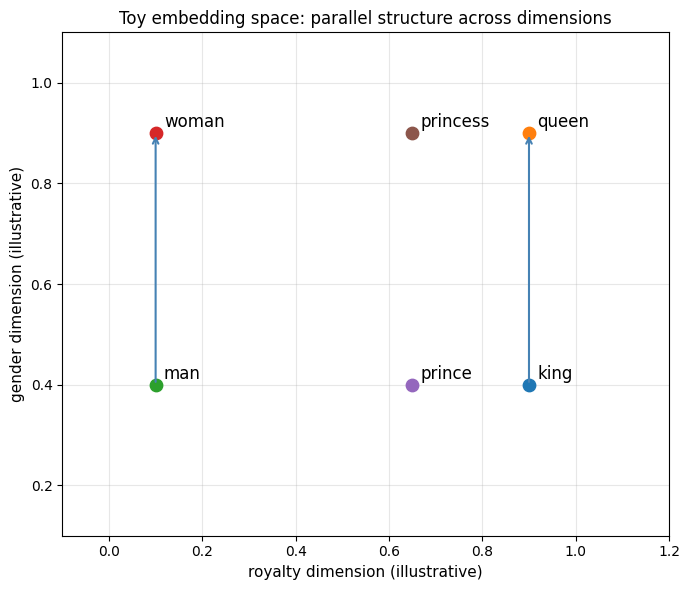

king - man + woman = [0.9 0.9]
queen               = [0.9 0.9]
(In a real embedding space these would be approximately equal)


In [6]:
# Illustration: a toy embedding space with hand-crafted 2D vectors
# Real embeddings have 50-300 dimensions and are learned from data.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# These 2D vectors are illustrative — not actual Word2Vec embeddings.
# Each axis loosely corresponds to "royalty" (x) and "gender" (y).
words = ["king", "queen", "man", "woman", "prince", "princess"]
vectors = np.array([
    [0.9,  0.4],   # king
    [0.9,  0.9],   # queen
    [0.1,  0.4],   # man
    [0.1,  0.9],   # woman
    [0.65, 0.4],   # prince
    [0.65, 0.9],   # princess
])

fig, ax = plt.subplots(figsize=(7, 6))
for word, vec in zip(words, vectors):
    ax.scatter(*vec, s=80, zorder=3)
    ax.annotate(word, vec, textcoords="offset points", xytext=(6, 4), fontsize=12)

# Draw the king → queen analogy arrow
ax.annotate("", xy=vectors[1], xytext=vectors[0],
            arrowprops=dict(arrowstyle="->", color="steelblue", lw=1.5))
ax.annotate("", xy=vectors[3], xytext=vectors[2],
            arrowprops=dict(arrowstyle="->", color="steelblue", lw=1.5))

ax.set_xlim(-0.1, 1.2)
ax.set_ylim(0.1, 1.1)
ax.set_xlabel("royalty dimension (illustrative)", fontsize=11)
ax.set_ylabel("gender dimension (illustrative)", fontsize=11)
ax.set_title("Toy embedding space: parallel structure across dimensions", fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("king - man + woman =", vectors[0] - vectors[2] + vectors[3])
print("queen               =", vectors[1])
print("(In a real embedding space these would be approximately equal)")

## A practical text classification pipeline

Now let's put these ideas to work with a real dataset and a full end-to-end pipeline.

### The 20 Newsgroups dataset

The **20 Newsgroups** dataset is a classic NLP benchmark: approximately 20,000 newsgroup posts drawn from 20 different discussion topics, ranging from `sci.space` to `rec.sport.hockey` to `talk.politics.guns`. The task is to classify a post into its correct newsgroup based on its text content.

This is a clean, well-studied problem that illustrates all the main challenges of text classification: a large vocabulary, varying document lengths, and topics that sometimes overlap (for example, `comp.sys.ibm.pc.hardware` vs. `comp.sys.mac.hardware`).

We will work with a subset of 6 categories to keep training time short while still demonstrating multi-class classification.

In [7]:
from sklearn.datasets import fetch_20newsgroups

categories = [
    'sci.space',
    'sci.med',
    'rec.sport.hockey',
    'rec.autos',
    'talk.politics.guns',
    'comp.graphics',
]

train = fetch_20newsgroups(subset='train', categories=categories,
                           remove=('headers', 'footers', 'quotes'),
                           random_state=42)
test  = fetch_20newsgroups(subset='test',  categories=categories,
                           remove=('headers', 'footers', 'quotes'),
                           random_state=42)

print(f"Training documents: {len(train.data)}")
print(f"Test documents:     {len(test.data)}")
print(f"Categories: {train.target_names}")

Training documents: 3511
Test documents:     2338
Categories: ['comp.graphics', 'rec.autos', 'rec.sport.hockey', 'sci.med', 'sci.space', 'talk.politics.guns']


In [8]:
# A sample post — this is the raw text our model will learn from
print("--- Sample post ---")
print(train.data[5])
print()
print("Category:", train.target_names[train.target[5]])

--- Sample post ---




In fact, you can all direct your ire at the proper target by ingoring NASA 
altogether.  The rocket is a commercial launch vechicle - a Conestoga flying 
a COMET payload.  NASA is simply the primary customer.  I believe SDIO has a
small payload as well.  The advertising space was sold by the owners of the
rocket, who can do whatever they darn well please with it.  In addition, these
anonymous "observers" had no reason to be startled.  The deal made Space News
at least twice. 




I think its only fair to find that out before everyone starts having a hissy
fit.  The fact that they bothered to use the conditional tense suggests that
it has not yet been approved.



Category: sci.space


### Building a pipeline: TF-IDF + Logistic Regression

A scikit-learn `Pipeline` chains together preprocessing and modeling steps so that:
1. The vectorizer is fit on training data only — the test vocabulary is whatever was seen during training.
2. The same transformation is automatically applied to test data before prediction.
3. No data leakage: the model never sees test statistics during training.

Our pipeline has two steps:
- **`TfidfVectorizer`**: tokenizes the raw text, builds the vocabulary, and converts each document to a TF-IDF weighted count vector. `max_features=20000` limits the vocabulary to the 20,000 most frequent terms (keeps things manageable). `ngram_range=(1,2)` includes both unigrams and bigrams.
- **`LogisticRegression`**: a multi-class logistic regression trained on the TF-IDF vectors. `max_iter=1000` gives the solver enough iterations to converge on this size of problem.

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1, 2),
                              sublinear_tf=True, min_df=2)),
    ('clf',   LogisticRegression(max_iter=1000, C=5.0, random_state=42)),
])

pipeline.fit(train.data, train.target)
predictions = pipeline.predict(test.data)

print(classification_report(test.target, predictions, target_names=test.target_names))

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=20000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('clf',
                 LogisticRegression(C=5.0, max_iter=1000, random_state=42))])

                    precision    recall  f1-score   support

     comp.graphics       0.86      0.85      0.86       389
         rec.autos       0.71      0.86      0.77       396
  rec.sport.hockey       0.94      0.89      0.92       399
           sci.med       0.83      0.80      0.81       396
         sci.space       0.83      0.77      0.80       394
talk.politics.guns       0.85      0.80      0.83       364

          accuracy                           0.83      2338
         macro avg       0.84      0.83      0.83      2338
      weighted avg       0.84      0.83      0.83      2338



### Reading the classification report

Each row corresponds to one newsgroup category. The columns are:

- **Precision**: of all the posts the model predicted for this category, what fraction actually belonged to it? High precision means few false positives.
- **Recall**: of all the posts that actually belonged to this category, what fraction did the model find? High recall means few false negatives.
- **F1-score**: the harmonic mean of precision and recall. Useful when you care about both.
- **Support**: the number of actual test documents in this category.

Notice that categories with distinct vocabularies (like `sci.space` or `rec.sport.hockey`) tend to get higher scores than more ambiguous categories. The model is essentially pattern-matching on characteristic terms — posts mentioning "orbit", "shuttle", "NASA" almost certainly belong to `sci.space`.

## Interactive demo: classify your own text

The model is trained. Now try it out. Type any sentence or short paragraph into the text box below and see which of the 6 newsgroup categories the model assigns it to, along with the probability it assigns to each category.

Try:
- Something about space exploration
- A sentence about car engines
- A sentence about hockey playoffs
- Something ambiguous — does the model handle it gracefully?

In [10]:
import ipywidgets as widgets
from IPython.display import display, clear_output

text_input = widgets.Textarea(
    value='The astronauts on the space station completed their EVA today.',
    placeholder='Type some text here...',
    description='Your text:',
    layout=widgets.Layout(width='100%', height='100px')
)

output = widgets.Output()

def classify_text(text):
    with output:
        clear_output(wait=True)
        if not text.strip():
            print("Please enter some text.")
            return
        pred_class = pipeline.predict([text])[0]
        probs = pipeline.predict_proba([text])[0]
        category_names = test.target_names
        print(f"Predicted category: {category_names[pred_class]}")
        print()
        print("Probability breakdown:")
        sorted_pairs = sorted(zip(category_names, probs), key=lambda x: -x[1])
        for name, prob in sorted_pairs:
            bar = '#' * int(prob * 40)
            print(f"  {name:<25} {bar:<40} {prob:.3f}")

def on_change(change):
    classify_text(change['new'])

text_input.observe(on_change, names='value')

display(text_input, output)
classify_text(text_input.value)

Textarea(value='The astronauts on the space station completed their EVA today.', description='Your text:', lay…

Output()

## Where TF-IDF falls short: sequence and context

The pipeline above works well for this task, but it has a fundamental limitation: it still treats each document as an unordered set of terms (augmented by bigrams). It cannot capture:

- **Long-range dependencies**: the subject of a sentence may be dozens of words away from its predicate.
- **Contextual meaning**: the word "bass" means different things in a fishing post and a music post, but TF-IDF gives it the same vector in both cases.
- **Sequential structure**: language unfolds in time. The meaning of each word depends on what came before it.

The next family of models — Recurrent Neural Networks — was specifically designed to address these issues.

## Recurrent Neural Networks (conceptual overview)

### The limitation of feedforward networks for sequences

A standard feedforward neural network takes a fixed-size input vector and produces a fixed-size output. If we feed it a TF-IDF document vector, the whole document is processed in a single forward pass, with no notion of sequence.

This is fine for classification on bag-of-words features, but it fails for tasks where the order of inputs matters — translating a sentence, generating text, labeling each word in a sequence with its part of speech, or predicting the next word. For these tasks, we need a model that can process one token at a time and remember what it has seen so far.

### RNNs: one word at a time, with memory

A **Recurrent Neural Network** processes a sequence step by step. At each time step $t$, it receives:
- The current input $x_t$ (the embedding of the current word)
- The **hidden state** $h_{t-1}$ from the previous step

And it produces:
- A new hidden state $h_t = f(W_x \cdot x_t + W_h \cdot h_{t-1} + b)$

That hidden state acts as a compressed memory of everything the model has read up to this point. After processing the entire sequence, $h_T$ summarizes the whole document — and can be used for classification, fed into a decoder for translation, or used to predict the next word.

The same weight matrices $W_x$ and $W_h$ are reused at every time step. This is what makes RNNs efficient: the number of parameters does not grow with sequence length.

### The vanishing gradient problem

Training an RNN requires backpropagating gradients through time — essentially unrolling the network into a very deep feedforward network (one layer per time step) and running backpropagation through the whole thing. For long sequences, this runs into a fundamental problem: **the vanishing gradient**.

As gradients are multiplied together across many time steps, they tend to shrink toward zero exponentially. By the time we reach early time steps (the beginning of the sequence), the gradient signal is so small that the weights there barely update. In practice, this means basic RNNs struggle to learn relationships between tokens that are more than 10–15 steps apart.

### LSTM: a carry track for long-range memory

The **Long Short-Term Memory** (LSTM) network was designed specifically to fix the vanishing gradient problem. The key innovation is a second internal channel called the **cell state** $c_t$ — sometimes called the "carry track" — that runs alongside the hidden state.

The cell state is modified through three **gates** — learned sigmoid-activated layers that control what information flows through:

1. **Forget gate**: decides which parts of the previous cell state to discard. If the model just finished reading a sentence about one topic and is starting a new one, the forget gate can wipe the cell state clean.
2. **Input gate**: decides what new information from the current input to write into the cell state.
3. **Output gate**: decides which parts of the cell state to expose as the hidden state $h_t$ (the part passed to the next step and used for predictions).

Because the cell state can be updated additively (add information in, drop information out) rather than multiplicatively across every step, gradients can flow backward through it without vanishing. This allows LSTMs to learn dependencies across hundreds of time steps — far more than basic RNNs.

### Where RNNs and LSTMs are used today

While Transformer-based models (BERT, GPT) have largely replaced RNNs for most state-of-the-art NLP tasks (they handle long-range dependencies even better and are faster to train in parallel), LSTMs are still widely used for:
- Time series modeling (financial data, sensor readings)
- Speech recognition at the acoustic model level
- Any task where sequential structure matters but the sequences are not extremely long

Understanding RNNs and LSTMs also gives you essential intuition for understanding why Transformers were designed the way they were — they are the solution to the same problem, approached differently.

## Summary

Here is the progression of ideas from this notebook:

| Representation | Captures | Misses |
|---|---|---|
| Bag of words | Word presence / frequency | Order, context, semantics |
| N-grams | Local word order | Long-range structure |
| One-hot encoding | Word identity | Semantic similarity |
| TF-IDF | Document-discriminative words | Order, context, semantics |
| Word embeddings | Semantic similarity, analogy | Context-dependent meaning |
| RNN / LSTM | Sequential structure, long-range deps | Parallelism, very long contexts |

The practical pipeline we built — `TfidfVectorizer` + `LogisticRegression` — is a strong baseline for many text classification tasks. It is fast to train, interpretable (you can look at the coefficients to see which terms are most predictive of each class), and often performs surprisingly well.

For more complex tasks — sentiment that depends on negation, coreference, question answering, summarization — you need representations that understand context and sequence, which is what embeddings, RNNs, and ultimately Transformers provide.